# Extreme precipitation: Past, Present, and Future changes

In this tutorial, we explore how **extreme precipitation** has changed over time and how it might change in the future for the Molise region in Italy (NUTS2 region ITF2). This tutorial thus focuses on the **hazard** and how it changes under climate change.

```{admonition} Learning Objectives
:class: tip
By the end of this tutorial, you will understand:
- How to analyze changes in extreme precipitation using the concept of return periods
- How to interpret future projections of extreme precipitation
- Why multiple climate models are essential for assessing uncertainty
- The importance of comparing projections to historical baselines
```

```{admonition} Prerequisites
:class: note
This tutorial uses preprocessed CSV data for the Molise region in Italy (ITF2). See the [How-To Guide on Projections of Precipitation](../how-to-guides/precipitation_c3satlas.ipynb) to download and process precipitation projections from the CDS. 
```

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

# Configure plotting
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Settings

In [2]:
# Configuration
admin_id = 'ITF2'

# Reference period for baseline statistics
baseline_start = 1976
baseline_end = 2005

# Analysis settings
rolling_window = 30  # years for rolling mean

# Paths
workdir = Path("/home/nejk/code/extreme_precip_exposure")
os.chdir(workdir)
data_dir = workdir / 'data' / admin_id / 'extreme_precip_exposure'

# Load preprocessed data
print(f"Region: {admin_id} (Molise, Italy)")
hist_file = data_dir / f'{admin_id}_precip_hist_amax_nutsmax.csv'
print(f"Historical data: {hist_file}")
proj_file = data_dir / f'{admin_id}_precip_proj_amax_nutsmax.csv'
print(f"Projection data: {proj_file}")

Region: ITF2 (Molise, Italy)
Historical data: /home/nejk/code/extreme_precip_exposure/data/ITF2/extreme_precip_exposure/ITF2_precip_hist_amax_nutsmax.csv
Projection data: /home/nejk/code/extreme_precip_exposure/data/ITF2/extreme_precip_exposure/ITF2_precip_proj_amax_nutsmax.csv


## Examining historical extreme precipitation 


### Using one climate model

We begin by examining the **historical record** of extreme precipitation using historical simulations from climate models. 

Let's load the historical data and visualize the extremes:

In [3]:
# Load historical data
hist_df = pd.read_csv(hist_file)
hist_df['year'] = pd.to_datetime(hist_df['year'], format='%Y')
hist_df = hist_df.sort_values('year')

print(f"Historical data: {hist_df['year'].min().year} to {hist_df['year'].max().year}, i.e., {hist_df['year'].max().year - hist_df['year'].min().year + 1} years")
print(f"Number of data entries: {len(hist_df)/(hist_df['year'].max().year - hist_df['year'].min().year + 1):.20f} entries per year")
hist_df.head()

# remove duplicate rows if any
hist_df = hist_df.drop_duplicates(subset=['year', 'member_id', 'rx1day'])
print(f"Number of data entries (after cleanup): {len(hist_df)/(hist_df['year'].max().year - hist_df['year'].min().year + 1):.20f} entries per year")


Historical data: 1970 to 2005, i.e., 36 years
Number of data entries: 142.00000000000000000000 entries per year
Number of data entries (after cleanup): 71.00000000000000000000 entries per year


Let's use one model's output first:

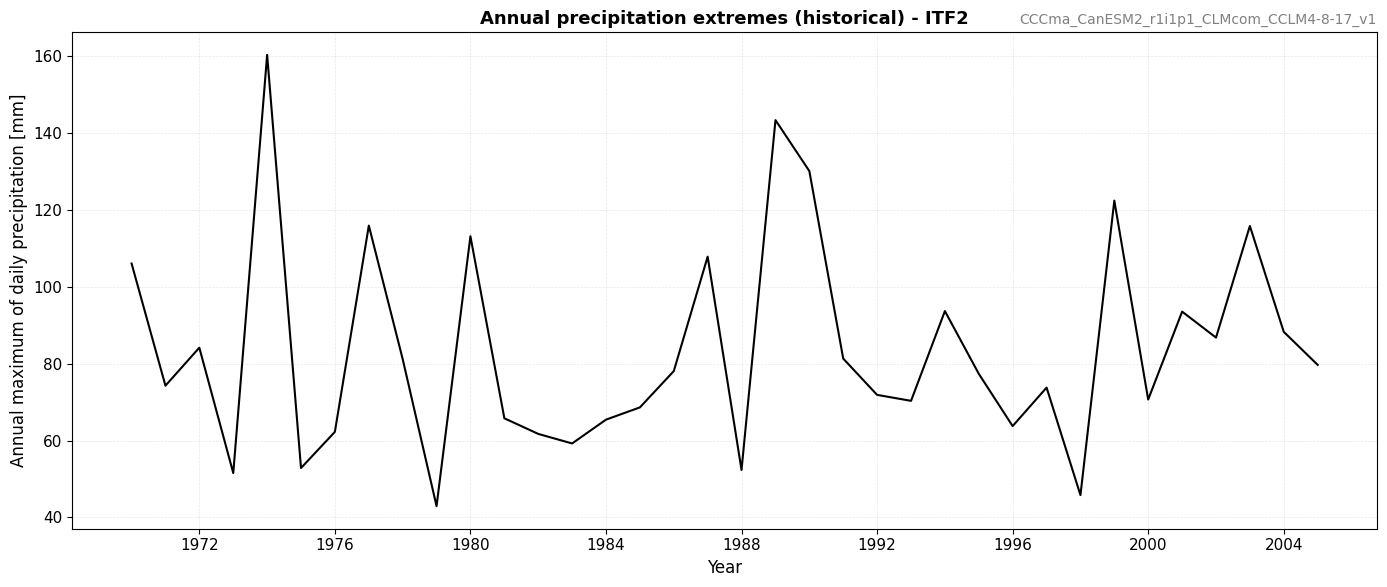


Historical annual maximum of daily precipitation statistics for CCCma_CanESM2_r1i1p1_CLMcom_CCLM4-8-17_v1:
  Mean: 83.67 mm/year
  Std: 27.78 mm/year
  Min: 42.91 mm/year (1979)
  Max: 160.36 mm/year (1974)


In [4]:
# Select one model (member) for demonstration (e.g., the first one)
hist_df_selected = hist_df[hist_df['member'] == hist_df['member'].unique()[0]].copy()
# Plot observed drought duration
fig, ax = plt.subplots(figsize=(14, 6))

# Plot annual values
ax.plot(hist_df_selected['year'], hist_df_selected['rx1day'], 
        color='black', linewidth=1.5, label='Annual maximum of daily precipitation [mm]')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Annual maximum of daily precipitation [mm]', fontsize=12)
ax.set_title(f'Annual precipitation extremes (historical) - {admin_id}', fontsize=13, fontweight='bold')
ax.set_title(f'{hist_df_selected["member_id"].iloc[0]}', loc='right', fontsize=10, color='gray')
#ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Calculate basic statistics
print(f"\nHistorical annual maximum of daily precipitation statistics for {hist_df_selected['member_id'].iloc[0]}:")
print(f"  Mean: {hist_df_selected['rx1day'].mean():.2f} mm/year")
print(f"  Std: {hist_df_selected['rx1day'].std():.2f} mm/year")
print(f"  Min: {hist_df_selected['rx1day'].min():.2f} mm/year ({hist_df_selected.loc[hist_df_selected['rx1day'].idxmin(), 'year'].year})")
print(f"  Max: {hist_df_selected['rx1day'].max():.2f} mm/year ({hist_df_selected.loc[hist_df_selected['rx1day'].idxmax(), 'year'].year})")

### Using the multi-model ensemble

Now let's see how the other climate models simulate the same historical period.

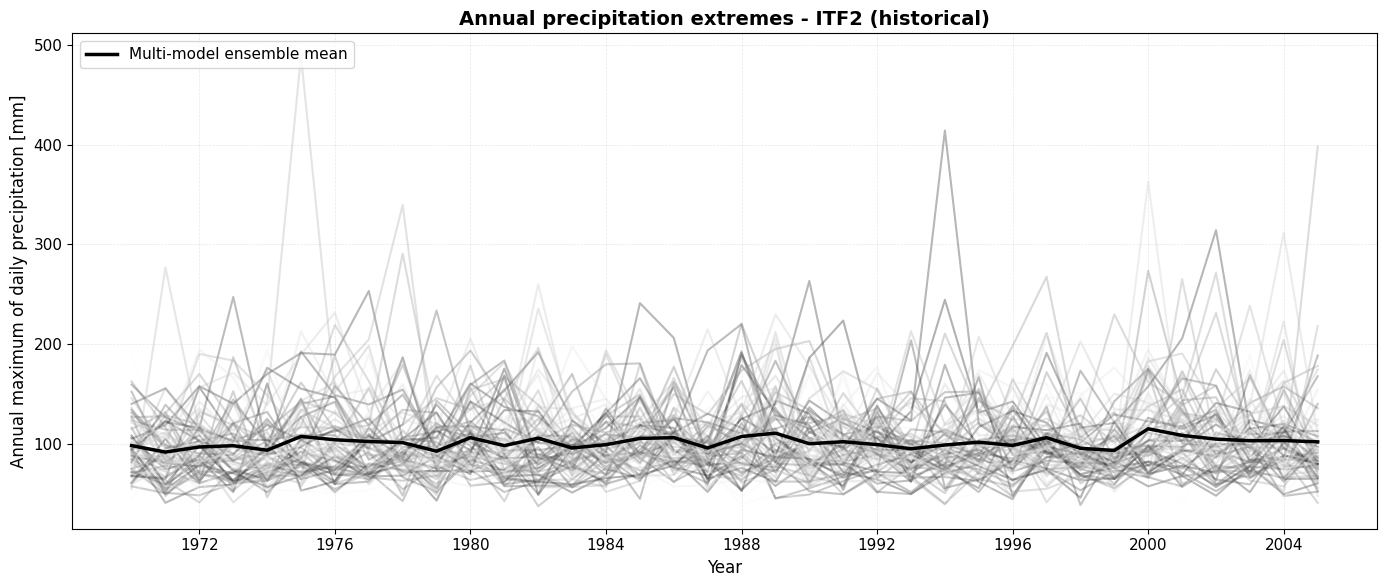

In [5]:
# plot climate model ensemble from hist_df using thin lines for each member and a thick line for the ensemble mean
ensemble_mean = hist_df.groupby('year')['rx1day'].mean()

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=hist_df, x='year', y='rx1day', hue='member', 
             palette='gray', alpha=0.3, legend=False, ax=ax)
sns.lineplot(x=ensemble_mean.index, y=ensemble_mean.values, 
             color='black', linewidth=2.5, label='Multi-model ensemble mean', ax=ax)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Annual maximum of daily precipitation [mm]', fontsize=12)
ax.set_title(f'Annual precipitation extremes - {admin_id} (historical)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Let's extract some first model statistics

In [6]:
# Print out statistics for the ensemble:
print(f"\nHistorical annual maximum of daily precipitation statistics (multi-model ensemble mean):")
print(f"  Mean: {ensemble_mean.mean():.2f} mm/year")
print(f"  Std: {ensemble_mean.std():.2f} mm/year")
print(f"  Min: {ensemble_mean.min():.2f} mm/year ({ensemble_mean.idxmin().year})")
print(f"  Max: {ensemble_mean.max():.2f} mm/year ({ensemble_mean.idxmax().year})")

# Single model statistics, for comparison
# Print out model with highest and lowest mean annual maximum of daily precipitation
model_means = hist_df.groupby('member_id')['rx1day'].mean()
print(f"\nModel with highest mean annual maximum of daily precipitation: {model_means.idxmax()} ({model_means.max():.2f} mm/year)")
print(f"Model with lowest mean annual maximum of daily precipitation: {model_means.idxmin()} ({model_means.min():.2f} mm/year)")
# Print out model and year with highest annual maximum of daily precipitation
max_row = hist_df.loc[hist_df['rx1day'].idxmax()]
print(f"Model and year with highest annual maximum of daily precipitation: {max_row['member_id']} ({max_row['year'].year}, {max_row['rx1day']:.2f} mm/year)")
# Print out model and year with lowest annual maximum of daily precipitation
min_row = hist_df.loc[hist_df['rx1day'].idxmin()]
print(f"Model and year with lowest annual maximum of daily precipitation:  {min_row['member_id']} ({min_row['year'].year}, {min_row['rx1day']:.2f} mm/year)")


Historical annual maximum of daily precipitation statistics (multi-model ensemble mean):
  Mean: 101.08 mm/year
  Std: 5.44 mm/year
  Min: 91.62 mm/year (1971)
  Max: 114.96 mm/year (2000)

Model with highest mean annual maximum of daily precipitation: CNRM-CERFACS_CNRM-CM5_r1i1p1_DMI_HIRHAM5_v2 (145.77 mm/year)
Model with lowest mean annual maximum of daily precipitation: NCC_NorESM1-M_r1i1p1_IPSL_WRF381P_v1 (66.58 mm/year)
Model and year with highest annual maximum of daily precipitation: MOHC_HadGEM2-ES_r1i1p1_UHOH_WRF361H_v1 (1975, 488.99 mm/year)
Model and year with lowest annual maximum of daily precipitation:  ICHEC_EC-EARTH_r3i1p1_CLMcom-ETH_COSMO-crCLIM-v1-1_v1 (1982, 37.30 mm/year)


## Extreme value statistics

Now, let's fit a generalised extreme value (GEV) distribution to these annual maxima to extract some robust (model-specific) extreme value statistics. 

In [7]:
# Fit a GEV to the annual maximum of daily precipitation for member=0 and print out the parameters 
from scipy.stats import genextreme
member_0_data = hist_df[hist_df['member'] == hist_df['member'].unique()[0]]['rx1day']
c, loc, scale = genextreme.fit(member_0_data)
print(f"\nFitted GEV parameters for member=0:")
print(f"  Shape (c): {c:.4f}")
print(f"  Location (loc): {loc:.2f} mm/year")
print(f"  Scale (scale): {scale:.2f} mm/year")


Fitted GEV parameters for member=0:
  Shape (c): -0.0529
  Location (loc): 70.66 mm/year
  Scale (scale): 20.51 mm/year


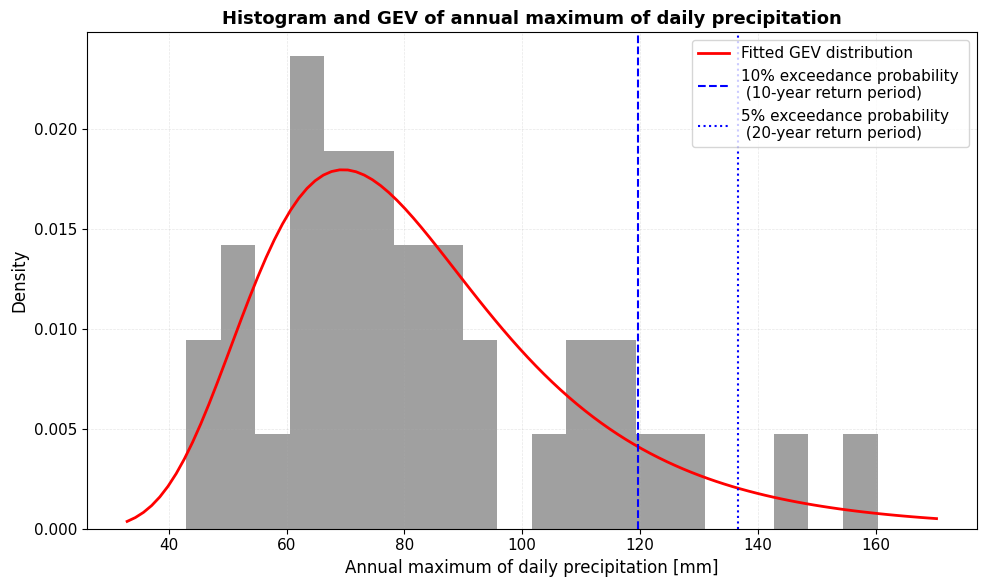

In [8]:
# Create a plot of the histogram of the annual maximum of daily precipitation for member=0 with the fitted GEV distribution overlaid
x = np.linspace(member_0_data.min() - 10, member_0_data.max() + 10, 100)
pdf_fitted = genextreme.pdf(x, c, loc, scale)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(member_0_data, bins=20, kde=False, stat='density', color='grey', edgecolor='None', ax=ax)
ax.plot(x, pdf_fitted, color='red', linewidth=2, label='Fitted GEV distribution')
ax.set_xlabel('Annual maximum of daily precipitation [mm]', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Histogram and GEV of annual maximum of daily precipitation', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# add vertical line for return period of 10 years (i.e., 10% exceedance probability)
return_period_10yr = genextreme.ppf(1 - 1/10, c, loc, scale)
ax.axvline(return_period_10yr, color='blue', linestyle='--', linewidth=1.5, label='10% exceedance probability \n (10-year return period)')
ax.legend(loc='upper right', fontsize=11, frameon=True)
# add vertical line for return period of 20 years (i.e., 5% exceedance probability)
return_period_20yr = genextreme.ppf(1 - 1/20, c, loc, scale)
ax.axvline(return_period_20yr, color='blue', linestyle=':', linewidth=1.5, label='5% exceedance probability \n (20-year return period)')
ax.legend(loc='upper right', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()


Estimated 100-year return level from fitted GEV for member=0: 177.48 mm/year


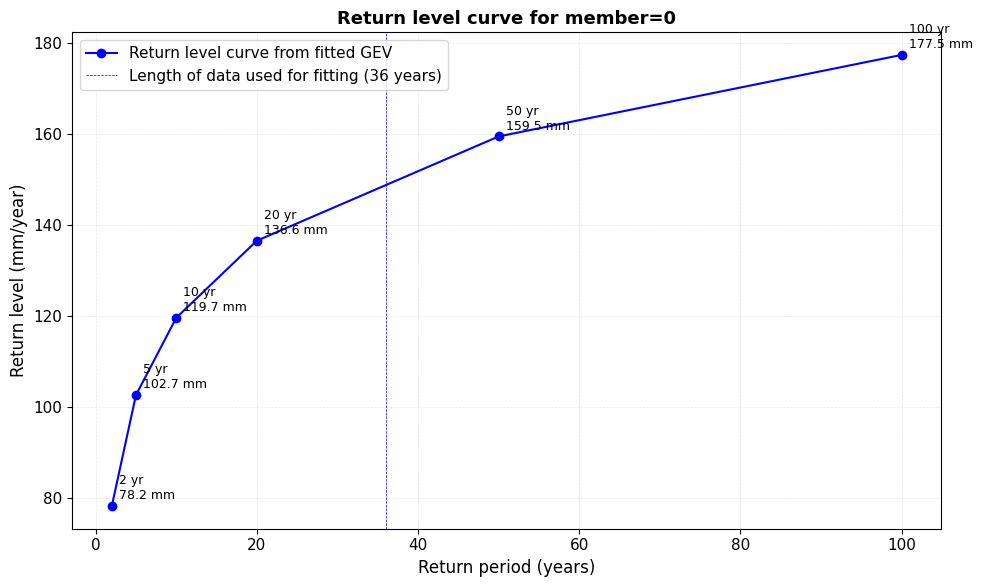

In [9]:
# Calculate return period from fitted GEV parameters for a 100-year event
return_period_100 = genextreme.ppf(1 - 1/100, c, loc, scale)
print(f"\nEstimated 100-year return level from fitted GEV for member=0: {return_period_100:.2f} mm/year")

# plot the return level curve for return periods from 2 to 100 years
return_periods = np.array([2, 5, 10, 20, 50, 100])
return_levels = genextreme.ppf(1 - 1/return_periods, c, loc, scale)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(return_periods, return_levels, marker='o', color='blue', label='Return level curve from fitted GEV')
#ax.set_xscale('log')
ax.set_xlabel('Return period (years)', fontsize=12)
ax.set_ylabel('Return level (mm/year)', fontsize=12)
ax.set_title(f'Return level curve for member=0', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# annotate all points with the return period and return level
for rp, rl in zip(return_periods, return_levels):
    ax.annotate(f'{rp} yr\n{rl:.1f} mm', xy=(rp, rl), xytext=(5, 5), textcoords='offset points', fontsize=9)
# add vertical line at length of years in dataset used for fitting
nyears = len(hist_df_selected)
ax.axvline(nyears, color='blue', linestyle='--', linewidth=0.5, label=f'Length of data used for fitting ({nyears} years)')
ax.legend(loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()    

In [ ]:
# repeat above plot but use a different reference period for fitting the GEV (e.g., 1975-2005 as set by baseline_start and baseline_end, instead of all years)
print(f"Processing baseline period: {baseline_start}-{baseline_end}")
hist_df_selected_period = hist_df_selected[(hist_df_selected['year'].dt.year.astype(int) >= baseline_start) & (hist_df_selected['year'].dt.year.astype(int) <= baseline_end)]   
nyears_baseline = len(hist_df_selected_period['year'])
print(hist_df_selected_period)
c, loc, scale = genextreme.fit(hist_df_selected_period['rx1day'].dropna())
return_periods = np.array([2, 5, 10, 20, 50, 100])
return_levels_baseline = genextreme.ppf(1 - 1/return_periods, c, loc, scale)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(return_periods, return_levels, marker='o', color='blue', label=f'Return level curve from fitted GEV ({nyears} years)')
ax.plot(return_periods, return_levels_baseline, marker='o', color='darkblue', label=f'Return level curve from fitted GEV ({nyears_baseline} years)')
#ax.set_xscale('log')
ax.set_xlabel('Return period [years]', fontsize=12)
ax.set_ylabel('Precipitation intensity [mm year$^{-1}$]', fontsize=12)
ax.set_title(f'Return level curve', fontsize=13, fontweight='bold')
ax.set_title(f'{hist_df_selected["member_id"].iloc[0]}', loc='right', fontsize=10, color='gray')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# annotate all points with the return period and return level
for rp, rl in zip(return_periods, return_levels):
    ax.annotate(f'{rp} yr\n{rl:.1f} mm', xy=(rp, rl), xytext=(5, 5), textcoords='offset points', fontsize=9, color='blue')
for rp, rl in zip(return_periods, return_levels_baseline):
    ax.annotate(f'{rp} yr\n{rl:.1f} mm', xy=(rp, rl), xytext=(5, 5), textcoords='offset points', fontsize=9, color='darkblue')
# add vertical line at length of years in dataset used for fitting
ax.axvline(nyears, color='blue', linestyle='--', linewidth=0.5, label=f'Length of data used for fitting ({nyears} years)')
ax.axvline(nyears, color='darkblue', linestyle='--', linewidth=0.5, label=f'Length of data used for fitting ({nyears_baseline} years)')
ax.legend(loc='lower right', fontsize=11, frameon=True)
plt.tight_layout()    

SyntaxError: f-string: single '}' is not allowed (2677212612.py, line 17)

CCCma_CanESM2_r1i1p1_CLMcom_CCLM4-8-17_v1
CCCma_CanESM2_r1i1p1_GERICS_REMO2015_v1
CNRM-CERFACS_CNRM-CM5_r1i1p1_CLMcom-ETH_COSMO-crCLIM-v1-1_v1
CNRM-CERFACS_CNRM-CM5_r1i1p1_CLMcom_CCLM4-8-17_v1
CNRM-CERFACS_CNRM-CM5_r1i1p1_CNRM_ALADIN63_v2
CNRM-CERFACS_CNRM-CM5_r1i1p1_DMI_HIRHAM5_v2
CNRM-CERFACS_CNRM-CM5_r1i1p1_GERICS_REMO2015_v2
CNRM-CERFACS_CNRM-CM5_r1i1p1_ICTP_RegCM4-6_v1
CNRM-CERFACS_CNRM-CM5_r1i1p1_IPSL_WRF381P_v2
CNRM-CERFACS_CNRM-CM5_r1i1p1_KNMI_RACMO22E_v2
CNRM-CERFACS_CNRM-CM5_r1i1p1_MOHC_HadREM3-GA7-05_v2
CNRM-CERFACS_CNRM-CM5_r1i1p1_SMHI_RCA4_v1
ICHEC_EC-EARTH_r12i1p1_CLMcom-ETH_COSMO-crCLIM-v1-1_v1
ICHEC_EC-EARTH_r12i1p1_CLMcom_CCLM4-8-17_v1
ICHEC_EC-EARTH_r12i1p1_DMI_HIRHAM5_v1
ICHEC_EC-EARTH_r12i1p1_GERICS_REMO2015_v1
ICHEC_EC-EARTH_r12i1p1_ICTP_RegCM4-6_v1
ICHEC_EC-EARTH_r12i1p1_IPSL_WRF381P_v1
ICHEC_EC-EARTH_r12i1p1_KNMI_RACMO22E_v1
ICHEC_EC-EARTH_r12i1p1_MOHC_HadREM3-GA7-05_v1
ICHEC_EC-EARTH_r12i1p1_SMHI_RCA4_v1
ICHEC_EC-EARTH_r12i1p1_UHOH_WRF361H_v1
ICHEC_EC-EARTH_r1i1

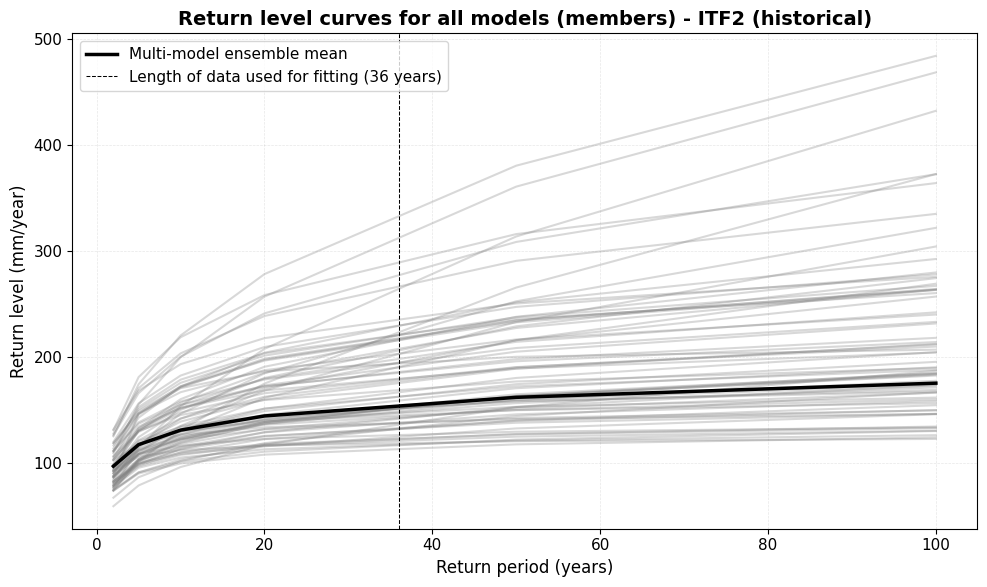

In [ ]:
# Create the same return level plot but plot all models (members) as thin lines and the ensemble mean as a thick line
fig, ax = plt.subplots(figsize=(10, 6))
for member_id, group in hist_df.groupby('member_id'):
    print(member_id)
    try:
        c, loc, scale = genextreme.fit(group['rx1day'].dropna())
        return_levels = genextreme.ppf(1 - 1/return_periods, c, loc, scale)
        ax.plot(return_periods, return_levels, color='gray', alpha=0.3)
    except Exception as e:
        print(f"Error fitting GEV for member {member_id}: {e}")
        print(f"Data for member {member_id}:")
        print(group['rx1day'])
# Plot ensemble mean return level curve
ensemble_return_levels = genextreme.ppf(1 - 1/return_periods, c, loc, scale)  # Using parameters from member=0 for simplicity
ax.plot(return_periods, ensemble_return_levels, color='black', linewidth=2.5, label='Multi-model ensemble mean')
ax.set_xlabel('Return period (years)', fontsize=12)
ax.set_ylabel('Return level (mm/year)', fontsize=12)
ax.set_title(f'Return level curves for all models (members) - {admin_id} (historical)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# add vertical line at length of years in dataset used for fitting
nyears = len(hist_df_selected)
ax.axvline(nyears, color='black', linestyle='--', linewidth=0.75, label=f'Length of data used for fitting ({nyears} years)')
ax.legend(loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()